Модель предсказания интроверт/экстраверт. 

Данные взяты из https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data/data

In [2]:
import pandas as pd

df = pd.read_csv("personality_dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [4]:
df.isna().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

<Axes: >

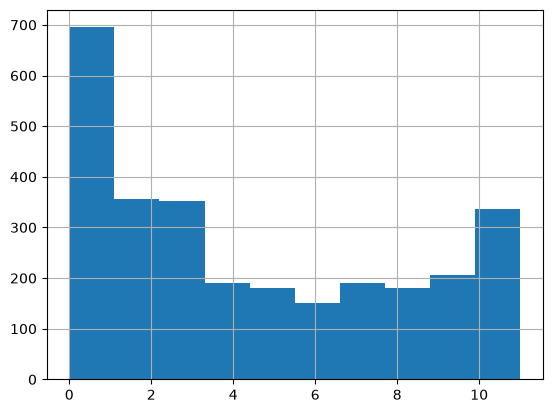

In [5]:
df['Time_spent_Alone'].hist()

In [6]:
df['Stage_fear'].value_counts()

Stage_fear
No     1417
Yes    1410
Name: count, dtype: int64

<Axes: >

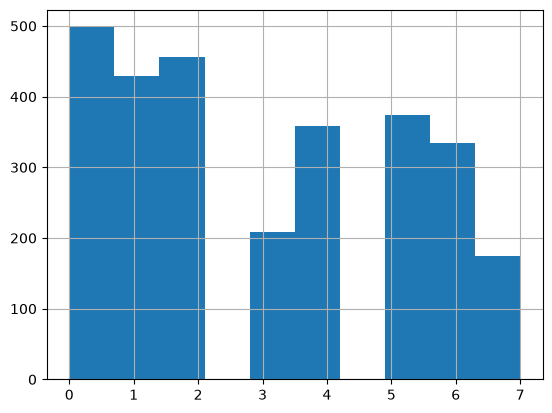

In [7]:
df['Going_outside'].hist()

In [8]:
df['Drained_after_socializing'].value_counts()

Drained_after_socializing
No     1441
Yes    1407
Name: count, dtype: int64

<Axes: >

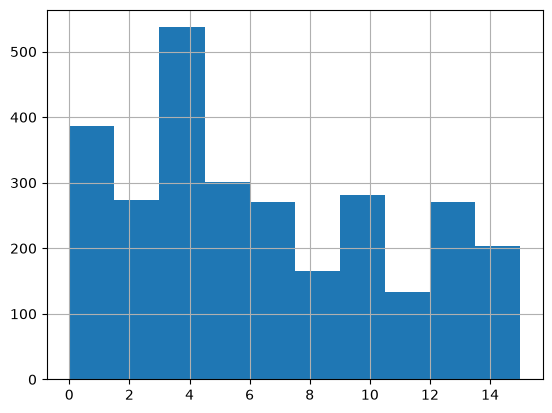

In [9]:
df['Friends_circle_size'].hist()

<Axes: >

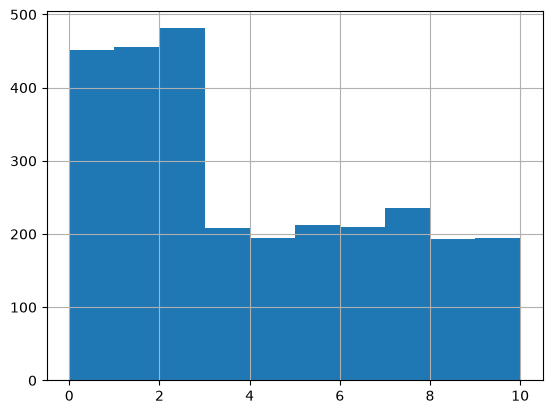

In [10]:
df['Post_frequency'].hist()

In [11]:
df.columns = df.columns.str.lower()

In [12]:
df['target'] = (df['personality'] == 'Extrovert').astype(int)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time_spent_alone           2837 non-null   float64
 1   stage_fear                 2827 non-null   str    
 2   social_event_attendance    2838 non-null   float64
 3   going_outside              2834 non-null   float64
 4   drained_after_socializing  2848 non-null   str    
 5   friends_circle_size        2823 non-null   float64
 6   post_frequency             2835 non-null   float64
 7   personality                2900 non-null   str    
 8   target                     2900 non-null   int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 204.0 KB


In [15]:
df = df.drop(columns='personality')

In [16]:
df.target.sum() / len(df)

np.float64(0.5141379310344828)

In [17]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

binary_cat_features = ['stage_fear', 'drained_after_socializing']
num_features = [
    'time_spent_alone', 
    'social_event_attendance',
    'going_outside', 
    'friends_circle_size', 
    'post_frequency'
]

cat_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[['No', 'Yes']] * 2, handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('imputer', KNNImputer(n_neighbors=3, add_indicator=True)),
])

num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3, add_indicator=True)),
    ('scaler', StandardScaler()),
])

col_transformer = ColumnTransformer(
    transformers=[
        ('cat_transformer', cat_pipeline, binary_cat_features),
        ('num_transformer', num_pipeline, num_features)
    ],
    remainder='passthrough',
    n_jobs=-1
)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(
    [
        ('column_preprocessing', col_transformer),
        ('estimator', LogisticRegression())
    ]
)

In [19]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns='target'), df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42,
    test_size=0.2,
    shuffle=True,
)

In [20]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('column_preprocessing', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['time_spent_alone','stage_fear','social_event_attendance',..., 'drained_after_socializing','friends_circle_size','post_frequency']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_transformer', ...), ('num_transformer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifi

In [21]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict(X_test)
roc_auc_score(y_test, y_pred)

0.9296893610939063

In [103]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

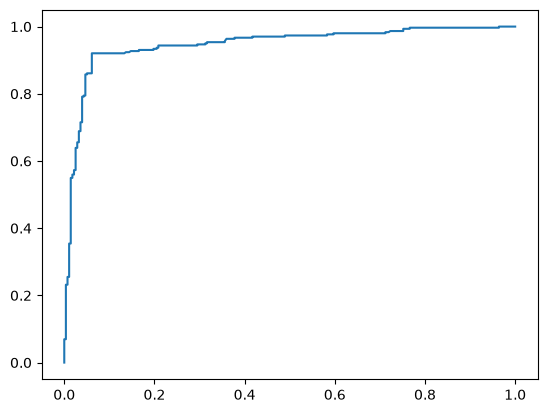

In [104]:
from matplotlib import pyplot as plt

plt.plot(fpr, tpr)

In [22]:
X.columns.tolist()

['time_spent_alone',
 'stage_fear',
 'social_event_attendance',
 'going_outside',
 'drained_after_socializing',
 'friends_circle_size',
 'post_frequency']

In [23]:
import joblib

bundle = {
    'pipeline': model,
    'metadata': {
        'version': '1.0.0',
        'features': X.columns.tolist(),
        'threshold': 0.5
    }
}
joblib.dump(bundle, "model.joblib")

['model.joblib']